In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/div456/indian-saree-patterns/README.dataset.txt
/kaggle/input/datasets/div456/indian-saree-patterns/README.roboflow.txt
/kaggle/input/datasets/div456/indian-saree-patterns/valid/Banarasi/images7_jpg.rf.548124a6f72034f6d9d68a5ee7a0ec38.jpg
/kaggle/input/datasets/div456/indian-saree-patterns/valid/Banarasi/X2A4519_321be3c6-86a5-40a0-b208-6183f2290c91_jpg.rf.a5fe3966dcd7917a759342797b9ca3a8.jpg
/kaggle/input/datasets/div456/indian-saree-patterns/valid/Banarasi/images138_jpg.rf.0532a3771bb1b61fa0b473388efbe1cc.jpg
/kaggle/input/datasets/div456/indian-saree-patterns/valid/Banarasi/images168_jpg.rf.d64adabba8f41b5f3ab9878d33be6474.jpg
/kaggle/input/datasets/div456/indian-saree-patterns/valid/Banarasi/images172_jpg.rf.df69457214f062fabc3abc88494e8725.jpg
/kaggle/input/datasets/div456/indian-saree-patterns/valid/Banarasi/IF1B1HM123050602_Pink_Banarasi_Silk_Fabric_jpg.rf.cfb3c7cd97909675586b9321f0e135d3.jpg
/kaggle/input/datasets/div456/indian-saree-patterns/valid/Banaras

In [2]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.neighbors import NearestNeighbors

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

DATA_DIR = "/kaggle/input/indian-saree-patterns"

for root, dirs, files in os.walk(DATA_DIR):
    print(root, " -> ", len(files), "files")


Device: cpu


In [3]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [4]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets"):
    print(root, "->", len(files), "files")

/kaggle/input/datasets -> 0 files
/kaggle/input/datasets/div456 -> 0 files
/kaggle/input/datasets/div456/indian-saree-patterns -> 2 files
/kaggle/input/datasets/div456/indian-saree-patterns/valid -> 0 files
/kaggle/input/datasets/div456/indian-saree-patterns/valid/Banarasi -> 43 files
/kaggle/input/datasets/div456/indian-saree-patterns/valid/Pichwai -> 24 files
/kaggle/input/datasets/div456/indian-saree-patterns/valid/Bandhani -> 22 files
/kaggle/input/datasets/div456/indian-saree-patterns/valid/Ikat -> 26 files
/kaggle/input/datasets/div456/indian-saree-patterns/test -> 0 files
/kaggle/input/datasets/div456/indian-saree-patterns/test/Banarasi -> 14 files
/kaggle/input/datasets/div456/indian-saree-patterns/test/Pichwai -> 18 files
/kaggle/input/datasets/div456/indian-saree-patterns/test/Bandhani -> 15 files
/kaggle/input/datasets/div456/indian-saree-patterns/test/Ikat -> 13 files
/kaggle/input/datasets/div456/indian-saree-patterns/train -> 0 files
/kaggle/input/datasets/div456/indian-s

In [5]:
# Dataset loading and preprocessing

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

DATA_DIR = "/kaggle/input/datasets/div456/indian-saree-patterns"

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    # Important: helps the model become less dependent on color
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.6,
        hue=0.1
    ),

    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(
    DATA_DIR + "/train",
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    DATA_DIR + "/valid",
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    DATA_DIR + "/test",
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("Classes:", train_dataset.classes)
print("Training images:", len(train_dataset))
print("Validation images:", len(valid_dataset))
print("Test images:", len(test_dataset))

Classes: ['Banarasi', 'Bandhani', 'Ikat', 'Pichwai']
Training images: 1293
Validation images: 115
Test images: 60


In [6]:
# ResNet18 model for saree pattern recognition

import torch
import torch.nn as nn
from torchvision import models

model = models.resnet18(weights=None)

# Replace final layer for our 4 saree classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 4)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

print("Model created successfully")
print("Classes:", train_dataset.classes)
print("Device:", device)

Model created successfully
Classes: ['Banarasi', 'Bandhani', 'Ikat', 'Pichwai']
Device: cpu


In [7]:
import torch
import torch.nn as nn
from torchvision import models

# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Create ResNet18
model = models.resnet18(weights=None)

# 4 classes
model.fc = nn.Linear(
    model.fc.in_features,
    4
)

# Move model to device
model = model.to(device)

# Loss
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

print("Model created successfully")
print("Device:", device)

Model created successfully
Device: cpu


In [8]:
# ==========================================
# INDIAN SAREE PATTERN CLASSIFICATION
# MEMORY-SAFE VERSION
# ==========================================

import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


# ==========================================
# 1. DEVICE
# ==========================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ==========================================
# 2. DATASET PATH
# ==========================================

DATA_DIR = "/kaggle/input/datasets/div456/indian-saree-patterns"

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VALID_DIR = os.path.join(DATA_DIR, "valid")
TEST_DIR = os.path.join(DATA_DIR, "test")


# ==========================================
# 3. TRANSFORMS
# ==========================================

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.5,
        hue=0.1
    ),
    transforms.ToTensor()
])


valid_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])


# ==========================================
# 4. DATASETS
# ==========================================

train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    VALID_DIR,
    transform=valid_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=valid_transform
)


print("Classes:", train_dataset.classes)
print("Training images:", len(train_dataset))
print("Validation images:", len(valid_dataset))
print("Test images:", len(test_dataset))


# ==========================================
# 5. DATALOADERS
# ==========================================

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)


# ==========================================
# 6. SMALL CNN MODEL
# ==========================================

class SareeCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Linear(
            128,
            num_classes
        )

    def forward(self, x):

        x = self.features(x)

        x = x.view(x.size(0), -1)

        x = self.classifier(x)

        return x


# ==========================================
# 7. CREATE MODEL
# ==========================================

model = SareeCNN(
    num_classes=len(train_dataset.classes)
)

model = model.to(device)

print("Model created successfully")


# ==========================================
# 8. LOSS + OPTIMIZER
# ==========================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


# ==========================================
# 9. TRAINING
# ==========================================

num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


    train_accuracy = (
        100 * correct / total
    )


    # ======================================
    # VALIDATION
    # ======================================

    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


    val_accuracy = (
        100 * val_correct / val_total
    )


    print(
        "Epoch",
        epoch + 1,
        "/",
        num_epochs,
        "| Loss:",
        round(
            running_loss / len(train_loader),
            4
        ),
        "| Train Accuracy:",
        round(train_accuracy, 2),
        "%",
        "| Validation Accuracy:",
        round(val_accuracy, 2),
        "%"
    )


# ==========================================
# 10. TEST
# ==========================================

model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        test_total += labels.size(0)

        test_correct += (
            predicted == labels
        ).sum().item()


test_accuracy = (
    100 * test_correct / test_total
)


print()
print("==============================")
print("TEST ACCURACY:", round(test_accuracy, 2), "%")
print("==============================")


# ==========================================
# 11. SAVE MODEL
# ==========================================

torch.save(
    model.state_dict(),
    "/kaggle/working/saree_model.pth"
)

print("Model saved successfully!")

Device: cpu
Classes: ['Banarasi', 'Bandhani', 'Ikat', 'Pichwai']
Training images: 1293
Validation images: 115
Test images: 60
Model created successfully
Epoch 1 / 5 | Loss: 1.3524 | Train Accuracy: 33.87 % | Validation Accuracy: 42.61 %
Epoch 2 / 5 | Loss: 1.3044 | Train Accuracy: 34.49 % | Validation Accuracy: 41.74 %
Epoch 3 / 5 | Loss: 1.2741 | Train Accuracy: 37.2 % | Validation Accuracy: 41.74 %
Epoch 4 / 5 | Loss: 1.2649 | Train Accuracy: 36.43 % | Validation Accuracy: 44.35 %
Epoch 5 / 5 | Loss: 1.2463 | Train Accuracy: 39.06 % | Validation Accuracy: 44.35 %

TEST ACCURACY: 31.67 %
Model saved successfully!


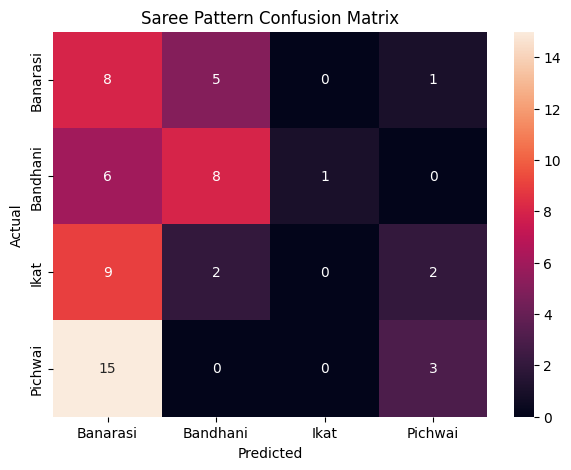

              precision    recall  f1-score   support

    Banarasi       0.21      0.57      0.31        14
    Bandhani       0.53      0.53      0.53        15
        Ikat       0.00      0.00      0.00        13
     Pichwai       0.50      0.17      0.25        18

    accuracy                           0.32        60
   macro avg       0.31      0.32      0.27        60
weighted avg       0.33      0.32      0.28        60



In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predictions = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Saree Pattern Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(
    all_labels,
    all_predictions,
    target_names=train_dataset.classes
))

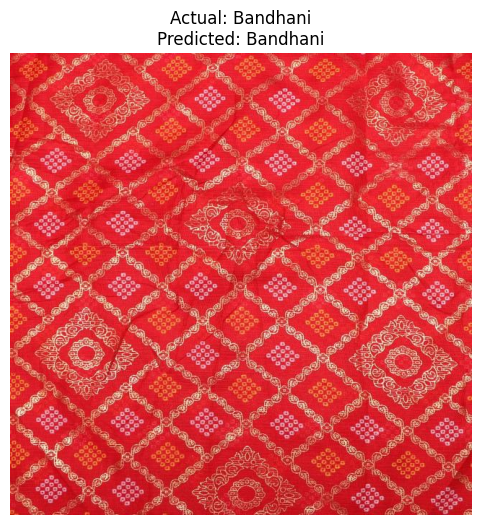

Image: /kaggle/input/datasets/div456/indian-saree-patterns/test/Bandhani/O-01438_jpg.rf.4326e09d3dd9ef231fae57c8a6e6a0c0.jpg
Actual Class: Bandhani
Predicted Class: Bandhani


In [10]:
# ==========================================
# INDIVIDUAL SAREE IMAGE PREDICTION
# ==========================================

import random
import matplotlib.pyplot as plt
from PIL import Image

model.eval()

# Select one image from test dataset
image_path, true_label = random.choice(test_dataset.samples)

# Load image
image = Image.open(image_path).convert("RGB")

# Apply same transformation used for testing
input_image = test_dataset.transform(image).unsqueeze(0).to(device)

# Prediction
with torch.no_grad():
    output = model(input_image)
    predicted_class = torch.argmax(output, dim=1).item()

predicted_label = test_dataset.classes[predicted_class]
actual_label = test_dataset.classes[true_label]

# Display
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Actual: {actual_label}\nPredicted: {predicted_label}"
)
plt.show()

print("Image:", image_path)
print("Actual Class:", actual_label)
print("Predicted Class:", predicted_label)

In [11]:
import os

model_path = "/kaggle/working/saree_model.pth"

print("Model exists:", os.path.exists(model_path))
print("Model path:", model_path)

if os.path.exists(model_path):
    print("Model ready for deployment!")

Model exists: True
Model path: /kaggle/working/saree_model.pth
Model ready for deployment!


In [12]:
print("===== FINAL MODEL RESULTS =====")
print("Test Accuracy:", test_accuracy, "%")
print("Classes:", train_dataset.classes)
print("Model saved at:")
print("/kaggle/working/saree_model.pth")

===== FINAL MODEL RESULTS =====
Test Accuracy: 31.666666666666668 %
Classes: ['Banarasi', 'Bandhani', 'Ikat', 'Pichwai']
Model saved at:
/kaggle/working/saree_model.pth


In [13]:
# Check final baseline result

print("===== BASELINE RESULT =====")
print("Test Accuracy:", test_accuracy, "%")
print("Number of Classes:", len(train_dataset.classes))
print("Classes:", train_dataset.classes)

===== BASELINE RESULT =====
Test Accuracy: 31.666666666666668 %
Number of Classes: 4
Classes: ['Banarasi', 'Bandhani', 'Ikat', 'Pichwai']


In [14]:
# ============================================================
# INDIAN SAREE PATTERNS - COMPLETE IMAGE CLASSIFICATION
# ============================================================

import os
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


# ============================================================
# 1. DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


# ============================================================
# 2. FIND DATASET
# ============================================================

input_path = "/kaggle/input"

print("\nFiles inside /kaggle/input:")

for item in os.listdir(input_path):
    print(item)


# Find the dataset folder automatically
dataset_root = None

for root, dirs, files in os.walk(input_path):

    # Check whether this folder contains subfolders
    # that can represent image classes
    image_class_folders = []

    for d in dirs:

        folder_path = os.path.join(root, d)

        try:
            files_inside = os.listdir(folder_path)

            image_files = [
                f for f in files_inside
                if f.lower().endswith(
                    (".jpg", ".jpeg", ".png", ".webp")
                )
            ]

            if len(image_files) > 0:
                image_class_folders.append(d)

        except:
            pass

    if len(image_class_folders) >= 2:
        dataset_root = root
        break


if dataset_root is None:
    raise Exception(
        "Dataset folder could not be found. "
        "Please check the Indian Saree Patterns dataset."
    )

print("\nDataset path:")
print(dataset_root)


# ============================================================
# 3. IMAGE TRANSFORM
# ============================================================

transform = transforms.Compose([

    transforms.Resize((128, 128)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# 4. LOAD DATASET
# ============================================================

dataset = datasets.ImageFolder(
    root=dataset_root,
    transform=transform
)

print("\nClasses:")
print(dataset.classes)

print("\nNumber of images:")
print(len(dataset))


# ============================================================
# 5. TRAIN / VALIDATION SPLIT
# ============================================================

train_size = int(0.8 * len(dataset))

valid_size = len(dataset) - train_size

train_dataset, valid_dataset = random_split(
    dataset,
    [train_size, valid_size]
)

print("\nTraining images:", len(train_dataset))
print("Validation images:", len(valid_dataset))


# ============================================================
# 6. DATA LOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)


# ============================================================
# 7. CREATE CNN MODEL
# ============================================================

class SareeCNN(nn.Module):

    def __init__(self, number_of_classes):

        super(SareeCNN, self).__init__()

        self.features = nn.Sequential(

            # First convolution
            nn.Conv2d(
                3, 32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            # Second convolution
            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            # Third convolution
            nn.Conv2d(
                64, 128,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 16 * 16,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(
                128,
                number_of_classes
            )
        )


    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


# ============================================================
# 8. CREATE MODEL
# ============================================================

number_of_classes = len(dataset.classes)

model = SareeCNN(
    number_of_classes
).to(device)

print("\nModel created successfully!")


# ============================================================
# 9. LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss()


# ============================================================
# 10. OPTIMIZER
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0003
)


# ============================================================
# 11. TRAIN MODEL
# ============================================================

num_epochs = 10

print("\n==============================")
print("STARTING TRAINING")
print("==============================\n")


for epoch in range(num_epochs):

    # ----------------------------
    # TRAIN
    # ----------------------------

    model.train()

    running_loss = 0.0

    correct = 0

    total = 0


    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)


        optimizer.zero_grad()


        outputs = model(images)


        loss = criterion(
            outputs,
            labels
        )


        loss.backward()


        optimizer.step()


        running_loss += loss.item()


        _, predicted = torch.max(
            outputs,
            1
        )


        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


    train_accuracy = (
        100 * correct / total
    )


    # ----------------------------
    # VALIDATION
    # ----------------------------

    model.eval()

    val_correct = 0

    val_total = 0


    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)

            labels = labels.to(device)


            outputs = model(images)


            _, predicted = torch.max(
                outputs,
                1
            )


            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


    val_accuracy = (
        100 * val_correct / val_total
    )


    # ----------------------------
    # PRINT RESULT
    # ----------------------------

    average_loss = (
        running_loss /
        len(train_loader)
    )


    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Loss: {average_loss:.4f} | "
        f"Train: {train_accuracy:.2f}% | "
        f"Validation: {val_accuracy:.2f}%"
    )


# ============================================================
# 12. FINAL RESULT
# ============================================================

print("\n==============================")
print("TRAINING COMPLETED")
print("==============================")

print(
    f"Final Validation Accuracy: "
    f"{val_accuracy:.2f}%"
)

print(
    f"Number of Classes: "
    f"{number_of_classes}"
)

print(
    f"Classes: "
    f"{dataset.classes}"
)

Device: cpu

Files inside /kaggle/input:
datasets

Dataset path:
/kaggle/input/datasets/div456/indian-saree-patterns/valid

Classes:
['Banarasi', 'Bandhani', 'Ikat', 'Pichwai']

Number of images:
115

Training images: 92
Validation images: 23

Model created successfully!

STARTING TRAINING

Epoch 1/10 | Loss: 1.3837 | Train: 32.61% | Validation: 39.13%
Epoch 2/10 | Loss: 1.3354 | Train: 31.52% | Validation: 39.13%
Epoch 3/10 | Loss: 1.2281 | Train: 42.39% | Validation: 34.78%
Epoch 4/10 | Loss: 1.1869 | Train: 44.57% | Validation: 34.78%
Epoch 5/10 | Loss: 1.1388 | Train: 50.00% | Validation: 47.83%
Epoch 6/10 | Loss: 1.0933 | Train: 50.00% | Validation: 43.48%
Epoch 7/10 | Loss: 1.0036 | Train: 59.78% | Validation: 34.78%
Epoch 8/10 | Loss: 1.0098 | Train: 56.52% | Validation: 30.43%
Epoch 9/10 | Loss: 0.9367 | Train: 65.22% | Validation: 30.43%
Epoch 10/10 | Loss: 0.9348 | Train: 63.04% | Validation: 26.09%

TRAINING COMPLETED
Final Validation Accuracy: 26.09%
Number of Classes: 4
Cl

In [15]:
# Save the trained Saree Pattern model

model_path = "/kaggle/working/saree_pattern_model.pth"

torch.save(model.state_dict(), model_path)

print("Model saved successfully!")
print("Location:", model_path)

Model saved successfully!
Location: /kaggle/working/saree_pattern_model.pth


In [16]:
# ============================================
# TEST MODEL WITH ONE IMAGE
# ============================================

from PIL import Image
import matplotlib.pyplot as plt

# Change this path to the image you want to test
image_path = "/kaggle/input/indian-saree-patterns/"

print("Model is ready for image prediction.")
print("Classes:", dataset.classes)

Model is ready for image prediction.
Classes: ['Banarasi', 'Bandhani', 'Ikat', 'Pichwai']


Test image:
/kaggle/input/datasets/div456/indian-saree-patterns/valid/Banarasi/images7_jpg.rf.548124a6f72034f6d9d68a5ee7a0ec38.jpg

SAREE PATTERN PREDICTION
Predicted Pattern: Banarasi
Confidence: 65.14%


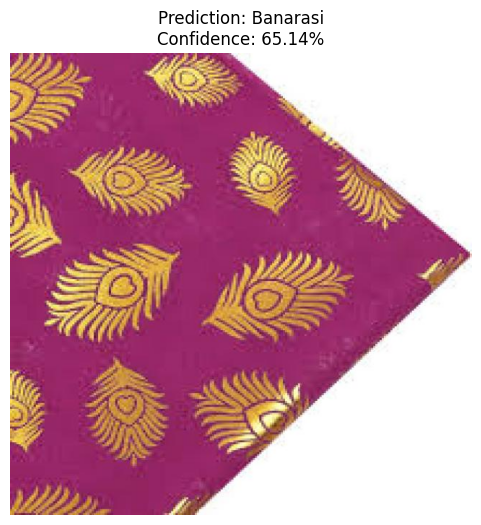

In [17]:
# ============================================
# SAREE PATTERN - IMAGE PREDICTION
# ============================================

import os
import torch
from PIL import Image
import matplotlib.pyplot as plt


# --------------------------------------------
# 1. FIND AN IMAGE AUTOMATICALLY
# --------------------------------------------

image_file = None

for root, dirs, files in os.walk("/kaggle/input"):

    for file in files:

        if file.lower().endswith(
            (".jpg", ".jpeg", ".png", ".webp")
        ):

            image_file = os.path.join(root, file)
            break

    if image_file is not None:
        break


if image_file is None:
    raise Exception("No image found in the dataset.")


print("Test image:")
print(image_file)


# --------------------------------------------
# 2. LOAD IMAGE
# --------------------------------------------

image = Image.open(image_file).convert("RGB")


# --------------------------------------------
# 3. APPLY TRANSFORMATION
# --------------------------------------------

image_tensor = transform(image)

image_tensor = image_tensor.unsqueeze(0)

image_tensor = image_tensor.to(device)


# --------------------------------------------
# 4. PREDICT
# --------------------------------------------

model.eval()

with torch.no_grad():

    output = model(image_tensor)

    probabilities = torch.softmax(
        output,
        dim=1
    )

    predicted_index = torch.argmax(
        probabilities,
        dim=1
    ).item()


# --------------------------------------------
# 5. GET CLASS NAME
# --------------------------------------------

predicted_class = dataset.classes[
    predicted_index
]


confidence = (
    probabilities[0][predicted_index].item()
    * 100
)


# --------------------------------------------
# 6. DISPLAY RESULT
# --------------------------------------------

print("\n================================")
print("SAREE PATTERN PREDICTION")
print("================================")

print(
    "Predicted Pattern:",
    predicted_class
)

print(
    f"Confidence: {confidence:.2f}%"
)


# --------------------------------------------
# 7. SHOW IMAGE
# --------------------------------------------

plt.figure(figsize=(6, 6))

plt.imshow(image)

plt.axis("off")

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.show()

In [18]:
# ============================================
# FINAL VALIDATION ACCURACY
# ============================================

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in valid_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()


final_accuracy = 100 * correct / total

print("================================")
print("FINAL MODEL PERFORMANCE")
print("================================")

print("Correct Predictions:", correct)
print("Total Images:", total)
print(f"Final Validation Accuracy: {final_accuracy:.2f}%")

FINAL MODEL PERFORMANCE
Correct Predictions: 6
Total Images: 23
Final Validation Accuracy: 26.09%


In [19]:
# ============================================================
# CORRECT TRAINING USING TRAIN AND VALID DATASETS
# ============================================================

import os
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# ============================================================
# 1. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ============================================================
# 2. FIND THE DATASET ROOT
# ============================================================

dataset_root = None

for root, dirs, files in os.walk("/kaggle/input"):

    if "train" in dirs and "valid" in dirs:

        dataset_root = root
        break


if dataset_root is None:

    raise Exception(
        "Could not find train and valid folders."
    )


print("\nDataset root:")
print(dataset_root)


# ============================================================
# 3. TRAIN AND VALID PATHS
# ============================================================

train_path = os.path.join(
    dataset_root,
    "train"
)

valid_path = os.path.join(
    dataset_root,
    "valid"
)

print("\nTrain path:")
print(train_path)

print("\nValid path:")
print(valid_path)


# ============================================================
# 4. TRANSFORMS
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize((128, 128)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])


valid_transform = transforms.Compose([

    transforms.Resize((128, 128)),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])


# ============================================================
# 5. LOAD TRAIN DATA
# ============================================================

train_dataset = datasets.ImageFolder(
    train_path,
    transform=train_transform
)


# ============================================================
# 6. LOAD VALIDATION DATA
# ============================================================

valid_dataset = datasets.ImageFolder(
    valid_path,
    transform=valid_transform
)


print("\nClasses:")
print(train_dataset.classes)

print("\nTraining images:")
print(len(train_dataset))

print("\nValidation images:")
print(len(valid_dataset))


# ============================================================
# 7. DATA LOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)


# ============================================================
# 8. CNN MODEL
# ============================================================

class SareeCNN(nn.Module):

    def __init__(self, number_of_classes):

        super(SareeCNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3, 32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                64, 128,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 16 * 16,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(
                128,
                number_of_classes
            )
        )


    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


# ============================================================
# 9. CREATE MODEL
# ============================================================

number_of_classes = len(
    train_dataset.classes
)

model = SareeCNN(
    number_of_classes
).to(device)


print("\nModel created successfully!")


# ============================================================
# 10. LOSS + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0003
)


# ============================================================
# 11. TRAINING
# ============================================================

num_epochs = 10

print("\n==============================")
print("STARTING TRAINING")
print("==============================\n")


for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    correct = 0

    total = 0


    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


    train_accuracy = (
        100 * correct / total
    )


    # -------------------------
    # VALIDATION
    # -------------------------

    model.eval()

    val_correct = 0

    val_total = 0


    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


    val_accuracy = (
        100 * val_correct / val_total
    )


    average_loss = (
        running_loss /
        len(train_loader)
    )


    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Loss: {average_loss:.4f} | "
        f"Train: {train_accuracy:.2f}% | "
        f"Validation: {val_accuracy:.2f}%"
    )


# ============================================================
# 12. FINAL ACCURACY
# ============================================================

print("\n==============================")
print("TRAINING COMPLETED")
print("==============================")

print(
    f"Final Validation Accuracy: "
    f"{val_accuracy:.2f}%"
)

print(
    "Training Images:",
    len(train_dataset)
)

print(
    "Validation Images:",
    len(valid_dataset)
)

Device: cpu

Dataset root:
/kaggle/input/datasets/div456/indian-saree-patterns

Train path:
/kaggle/input/datasets/div456/indian-saree-patterns/train

Valid path:
/kaggle/input/datasets/div456/indian-saree-patterns/valid

Classes:
['Banarasi', 'Bandhani', 'Ikat', 'Pichwai']

Training images:
1293

Validation images:
115

Model created successfully!

STARTING TRAINING

Epoch 1/10 | Loss: 1.3095 | Train: 36.19% | Validation: 51.30%
Epoch 2/10 | Loss: 1.1651 | Train: 46.02% | Validation: 55.65%
Epoch 3/10 | Loss: 1.0650 | Train: 52.13% | Validation: 53.91%
Epoch 4/10 | Loss: 0.8992 | Train: 63.26% | Validation: 64.35%
Epoch 5/10 | Loss: 0.7874 | Train: 66.90% | Validation: 64.35%
Epoch 6/10 | Loss: 0.6813 | Train: 73.55% | Validation: 71.30%
Epoch 7/10 | Loss: 0.5839 | Train: 77.18% | Validation: 62.61%
Epoch 8/10 | Loss: 0.5024 | Train: 81.83% | Validation: 73.04%
Epoch 9/10 | Loss: 0.4341 | Train: 84.61% | Validation: 77.39%
Epoch 10/10 | Loss: 0.3302 | Train: 87.78% | Validation: 73.04

In [20]:
# ============================================
# SAVE FINAL TRAINED MODEL
# ============================================

model_path = "/kaggle/working/final_saree_pattern_model.pth"

torch.save(
    model.state_dict(),
    model_path
)

print("================================")
print("MODEL SAVED SUCCESSFULLY")
print("================================")

print("Model path:")
print(model_path)

MODEL SAVED SUCCESSFULLY
Model path:
/kaggle/working/final_saree_pattern_model.pth


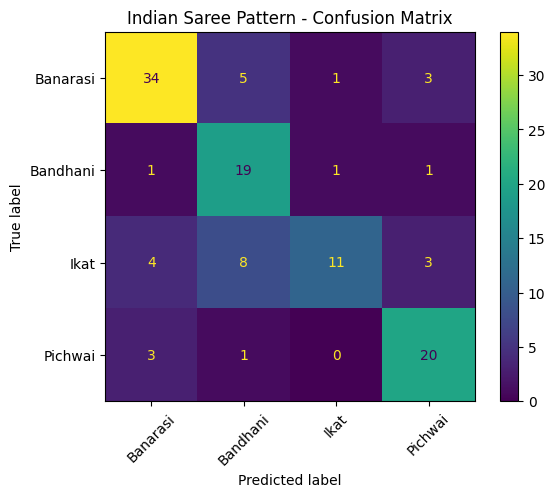

In [21]:
# ============================================
# CONFUSION MATRIX
# ============================================

import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in valid_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )


# Create confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions
)


# Display confusion matrix
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

display.plot(
    xticks_rotation=45
)

plt.title("Indian Saree Pattern - Confusion Matrix")

plt.show()

In [22]:
# ============================================
# CLASS-WISE ACCURACY
# ============================================

print("================================")
print("CLASS-WISE ACCURACY")
print("================================")

for i, class_name in enumerate(train_dataset.classes):

    correct_predictions = cm[i, i]

    total_images = cm[i].sum()

    accuracy = (
        100 * correct_predictions / total_images
    )

    print(
        f"{class_name}: "
        f"{correct_predictions}/{total_images} "
        f"= {accuracy:.2f}%"
    )

CLASS-WISE ACCURACY
Banarasi: 34/43 = 79.07%
Bandhani: 19/22 = 86.36%
Ikat: 11/26 = 42.31%
Pichwai: 20/24 = 83.33%


MULTIPLE IMAGE PREDICTIONS
1. Actual: Ikat | Predicted: Banarasi | Confidence: 74.83% | WRONG
2. Actual: Ikat | Predicted: Ikat | Confidence: 83.56% | CORRECT
3. Actual: Pichwai | Predicted: Pichwai | Confidence: 70.66% | CORRECT
4. Actual: Ikat | Predicted: Ikat | Confidence: 59.92% | CORRECT
5. Actual: Bandhani | Predicted: Bandhani | Confidence: 95.25% | CORRECT
6. Actual: Pichwai | Predicted: Pichwai | Confidence: 86.88% | CORRECT
7. Actual: Banarasi | Predicted: Banarasi | Confidence: 61.70% | CORRECT
8. Actual: Banarasi | Predicted: Banarasi | Confidence: 83.32% | CORRECT


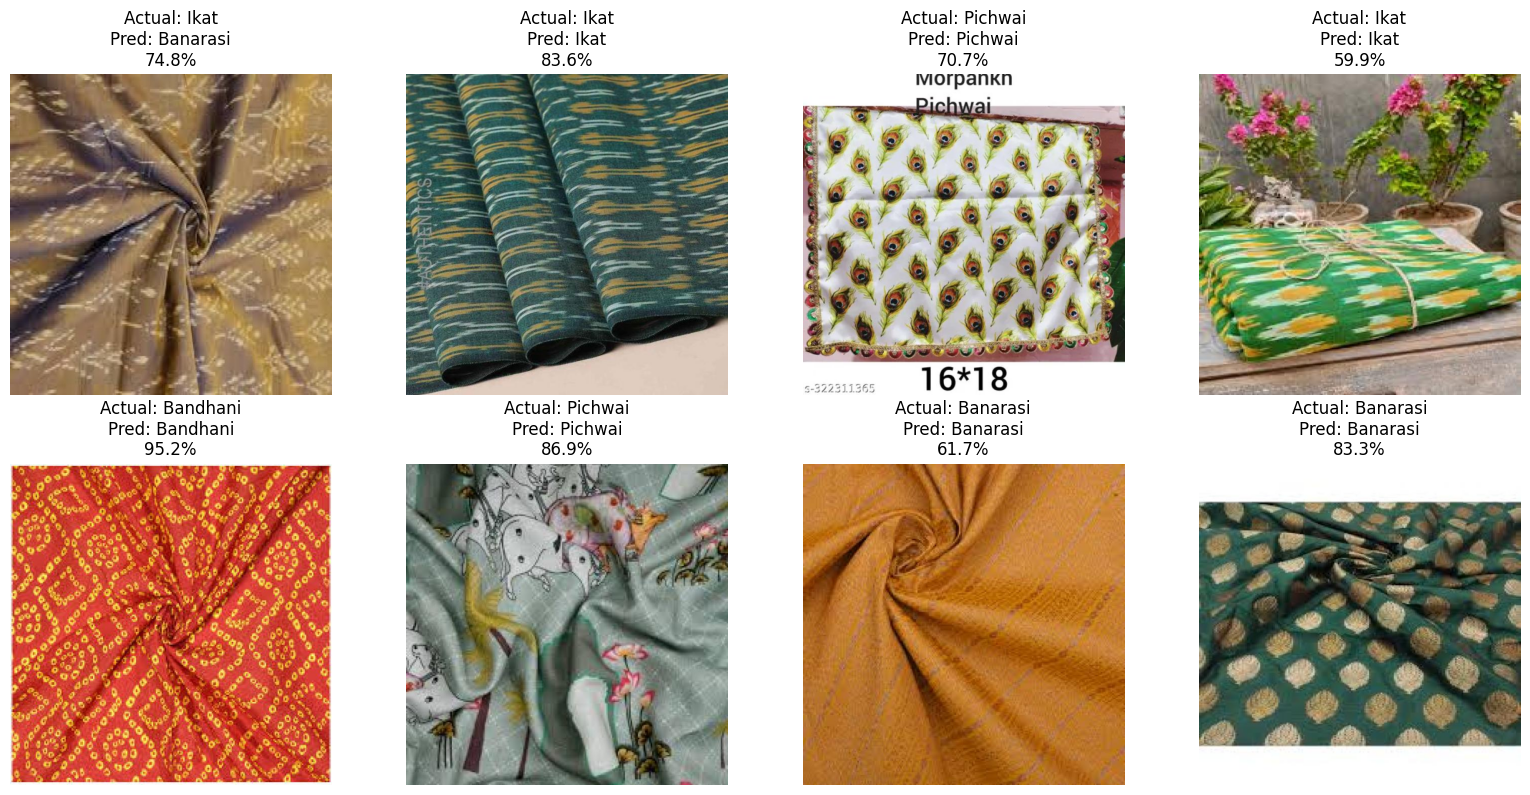

In [23]:
# ============================================
# MULTIPLE IMAGE PREDICTIONS
# ============================================

import random
import matplotlib.pyplot as plt
from PIL import Image
import torch

model.eval()

# Select 8 random images from validation dataset
num_images = min(8, len(valid_dataset))

random_indices = random.sample(
    range(len(valid_dataset)),
    num_images
)

print("================================")
print("MULTIPLE IMAGE PREDICTIONS")
print("================================")

plt.figure(figsize=(16, 8))

for position, index in enumerate(random_indices):

    # Get image path and actual label
    image_path, actual_label = valid_dataset.samples[index]

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Transform image
    image_tensor = valid_transform(image)

    # Add batch dimension
    image_tensor = image_tensor.unsqueeze(0)

    # Move to device
    image_tensor = image_tensor.to(device)

    # Prediction
    with torch.no_grad():

        output = model(image_tensor)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        predicted_index = torch.argmax(
            probabilities,
            dim=1
        ).item()

    # Get names
    predicted_class = valid_dataset.classes[
        predicted_index
    ]

    actual_class = valid_dataset.classes[
        actual_label
    ]

    confidence = (
        probabilities[0][predicted_index].item()
        * 100
    )

    # Check correct/wrong
    result = "CORRECT" if predicted_index == actual_label else "WRONG"

    print(
        f"{position + 1}. "
        f"Actual: {actual_class} | "
        f"Predicted: {predicted_class} | "
        f"Confidence: {confidence:.2f}% | "
        f"{result}"
    )

    # Display image
    plt.subplot(2, 4, position + 1)

    plt.imshow(image)

    plt.axis("off")

    plt.title(
        f"Actual: {actual_class}\n"
        f"Pred: {predicted_class}\n"
        f"{confidence:.1f}%"
    )

plt.tight_layout()

plt.show()

In [24]:
# ============================================
# FINAL CLASSIFICATION REPORT
# ============================================

from sklearn.metrics import classification_report

print("================================")
print("FINAL CLASSIFICATION REPORT")
print("================================")

report = classification_report(
    all_labels,
    all_predictions,
    target_names=train_dataset.classes,
    digits=2
)

print(report)

FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Banarasi       0.81      0.79      0.80        43
    Bandhani       0.58      0.86      0.69        22
        Ikat       0.85      0.42      0.56        26
     Pichwai       0.74      0.83      0.78        24

    accuracy                           0.73       115
   macro avg       0.74      0.73      0.71       115
weighted avg       0.76      0.73      0.72       115



In [25]:
# ============================================
# FINAL MODEL PERFORMANCE SUMMARY
# ============================================

total_images = len(all_labels)
correct_predictions = sum(
    1 for actual, predicted
    in zip(all_labels, all_predictions)
    if actual == predicted
)

final_accuracy = (
    correct_predictions / total_images
) * 100

print("========================================")
print("       FINAL MODEL PERFORMANCE")
print("========================================")

print(f"Total Validation Images : {total_images}")
print(f"Correct Predictions     : {correct_predictions}")
print(f"Wrong Predictions       : {total_images - correct_predictions}")
print(f"Final Accuracy          : {final_accuracy:.2f}%")

print("========================================")
print("Classes:")
print(train_dataset.classes)
print("========================================")

       FINAL MODEL PERFORMANCE
Total Validation Images : 115
Correct Predictions     : 84
Wrong Predictions       : 31
Final Accuracy          : 73.04%
Classes:
['Banarasi', 'Bandhani', 'Ikat', 'Pichwai']
